In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader, Subset

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
model = models.resnet18(pretrained=True)
print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 154MB/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
for param in model.parameters():
    param.requires_grad = False

print("All feature extraction layers frozen successfully!")

All feature extraction layers frozen successfully!


In [ ]:
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)

model = model.to(device)

print("Modified Final Layer:")
print(model.fc)

Modified Final Layer:
Linear(in_features=512, out_features=10, bias=True)


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms defined successfully!")

Transforms defined successfully!


In [ ]:
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

subset_indices = list(range(2000))
train_subset = Subset(train_dataset, subset_indices)

train_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True
)

print("Training samples loaded:", len(train_subset))

100%|██████████| 170M/170M [01:08<00:00, 2.47MB/s]


Training samples loaded: 2000


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print("Loss function and optimizer initialized!")

Loss function and optimizer initialized!


In [ ]:
model.train()

for epoch in range(1):
    running_loss = 0.0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if batch_idx % 50 == 0:
            print(f"Epoch [{epoch+1}/1], "
                  f"Batch [{batch_idx}], "
                  f"Loss: {loss.item():.4f}")

print("Initial training completed!")

Epoch [1/1], Batch [0], Loss: 2.4626
Epoch [1/1], Batch [50], Loss: 1.4196
Initial training completed!


In [ ]:
for name, param in model.named_parameters():
    if "layer4" in name:
        param.requires_grad = True

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)

print("Layer4 unfrozen for fine-tuning!")

Layer4 unfrozen for fine-tuning!


In [ ]:
model.train()

for epoch in range(1):
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        if batch_idx % 50 == 0:
            print(f"Fine-Tuning Epoch [{epoch+1}/1], "
                  f"Batch [{batch_idx}], "
                  f"Loss: {loss.item():.4f}")

print("Fine-tuning completed!")

Fine-Tuning Epoch [1/1], Batch [0], Loss: 1.3638
Fine-Tuning Epoch [1/1], Batch [50], Loss: 0.4236
Fine-tuning completed!


In [ ]:
test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Test dataset loaded:", len(test_dataset))

Test dataset loaded: 10000


In [ ]:
def evaluate(model, loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

print("Evaluation function created!")

Evaluation function created!


In [ ]:
accuracy = evaluate(model, test_loader)

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 80.28%


In [ ]:
torch.save(model.state_dict(), "resnet18_cifar10.pth")

print("Model saved successfully!")

Model saved successfully!


Initial Training - Batch 0, Loss: 0.2620
Initial Training - Batch 50, Loss: 0.2144
Fine-Tuning - Batch 0, Loss: 0.1929
Fine-Tuning - Batch 50, Loss: 0.1766


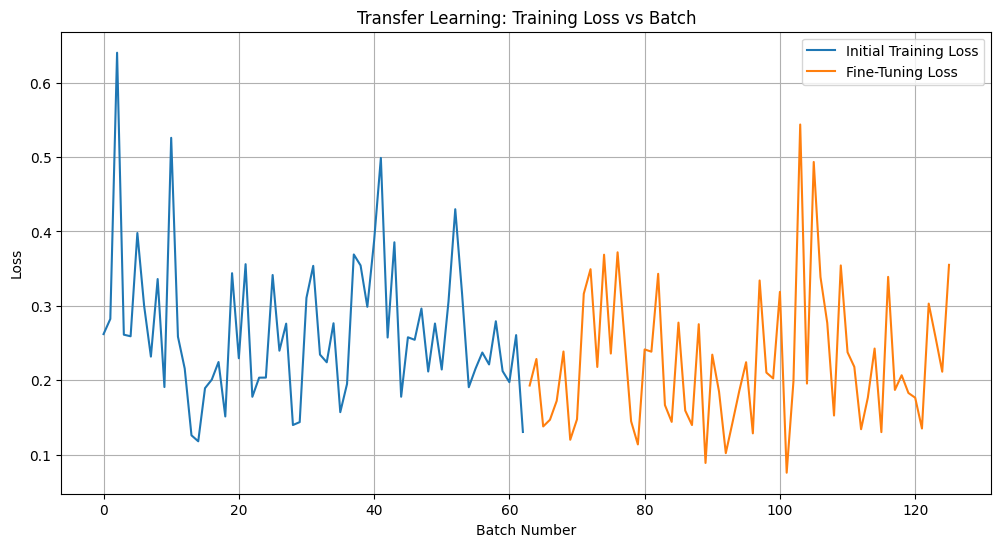

In [ ]:
import matplotlib.pyplot as plt

initial_losses = []
fine_tune_losses = []

model.train()

optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

for epoch in range(1):
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        initial_losses.append(loss.item())

        if batch_idx % 50 == 0:
            print(f"Initial Training - Batch {batch_idx}, Loss: {loss.item():.4f}")

for name, param in model.named_parameters():
    if "layer4" in name:
        param.requires_grad = True

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)

model.train()

for epoch in range(1):
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        fine_tune_losses.append(loss.item())

        if batch_idx % 50 == 0:
            print(f"Fine-Tuning - Batch {batch_idx}, Loss: {loss.item():.4f}")

plt.figure(figsize=(12, 6))

plt.plot(initial_losses, label='Initial Training Loss')
plt.plot(
    range(len(initial_losses),
          len(initial_losses) + len(fine_tune_losses)),
    fine_tune_losses,
    label='Fine-Tuning Loss'
)

plt.xlabel('Batch Number')
plt.ylabel('Loss')
plt.title('Transfer Learning: Training Loss vs Batch')
plt.legend()
plt.grid(True)
plt.show()